In [1]:
import os
import gc

os.chdir('../../')

In [3]:
import mlflow
import pandas as pd
import numpy as np
import catboost as cb
import json
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from boruta import BorutaPy
from sklearn.ensemble import RandomForestRegressor

# For MAPIE Conformal
from mapie.metrics import (regression_coverage_score,
                           regression_mean_width_score)

from sklearn.metrics import mean_squared_error

In [4]:
mlflow.set_experiment('different_targets')

<Experiment: artifact_location='file:///Users/henriquecosta/workspace/studies/modern-ml/mlruns/934786272341439840', creation_time=1739313701825, experiment_id='934786272341439840', last_update_time=1739313701825, lifecycle_stage='active', name='different_targets', tags={}>

In [9]:
def plot_prediction_vs_actual(run_name, y_val, median, lower_bound, upper_bound):
    plt.figure(figsize=(10,5))
    result_df = pd.DataFrame({
        "y_val": y_val,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "median_pred": median
    })
    sns.scatterplot(x='median_pred', y='y_val', data=result_df, marker='o', linestyle='', alpha=0.9)
    plt.errorbar(result_df['median_pred'], result_df['y_val'], 
                 yerr=(result_df['upper_bound'] - result_df['lower_bound']), fmt='o', color='blue', alpha=0.7, ecolor='gray', elinewidth=1, capsize=3)
    plt.legend()
    plt.title(run_name)
    plt.xlabel("Predicted Price")
    plt.ylabel("True Price")
    plt.savefig("actua_price_versus_predicted_price.png", bbox_inches='tight')
    mlflow.log_artifact("actua_price_versus_predicted_price.png")
    plt.show()

def log_metrics(run_name, y_val, median, lower_bound, upper_bound):
    # Compute metrics
    rmse = np.sqrt(mean_squared_error(y_val, median))
    coverage = regression_coverage_score(y_val, lower_bound, upper_bound)
    width = regression_mean_width_score(lower_bound, upper_bound)

    # Log metrics
    print('Logging metrics to MLflow: ', run_name, ' ....')
    mlflow.log_param("quantile_levels", quantile_levels)
    mlflow.log_metric("rmse", rmse)
    
    mlflow.log_metric("mape", np.mean(np.abs((y_val - median) / y_val)) * 100)
    mlflow.log_metric("mae", np.mean(np.abs(y_val - median)))
    mlflow.log_metric("mdape", np.median(np.abs((y_val - median) / y_val)) * 100)

    mlflow.log_metric("coverage", coverage)
    mlflow.log_metric("interval_width", width)
    
    

    # Print metrics
    print(run_name)
    print("quantile_levels", quantile_levels)
    print("RMSE:", rmse)
    print("MAPE:", np.mean(np.abs((y_val - median) / y_val)) * 100)
    print("MAE:", np.mean(np.abs(y_val - median)))
    print("MDAPE:", np.median(np.abs((y_val - median) / y_val)) * 100)
    print("Coverage:", coverage)
    print("Interval Width:", width)

In [10]:
# Load data week_2/data/processed/sg-resale-flat-prices-engineered.parquet
df = pd.read_parquet('week_2/data/processed/sg-resale-flat-prices-engineered.parquet')

# Load features list
with open('week_2/data/processed/features_list.json', 'r') as f:
    features_list = json.load(f)

In [12]:
split_date_train_end = pd.to_datetime("2024-01-01")
split_date_val_cal = pd.to_datetime("2024-07-01")

train_mask = (df['month'] < split_date_train_end)
val_cal_mask = (df['month'] >= split_date_train_end) & (df['month'] < split_date_val_cal)

df_train = df.loc[train_mask].copy()
df_val_cal = df.loc[val_cal_mask].copy()

# Now we split df_val_cal 50/50 with random split

np.random.seed(42)
mask = np.random.rand(len(df_val_cal)) < 0.5
df_val = df_val_cal[mask].copy()
df_cal = df_val_cal[~mask].copy()


print("Training set size:", df_train.shape)
print("Validation set size:", df_val.shape)
print("Calibration set size:", df_cal.shape)

# Features (X) and target (y) - We'll use 'corrected_price' as target
X_train = df_train[features_list].copy()
y_train = df_train['corrected_price'].copy()

X_val = df_val[features_list].copy()
y_val = df_val['resale_price'].copy()

X_cal = df_cal[features_list].copy()
y_cal = df_cal['resale_price'].copy()

Training set size: (104896, 68)
Validation set size: (6119, 68)
Calibration set size: (5991, 68)


In [13]:
# Select cat features with dtype category
cat_features = X_train.select_dtypes(include=['category']).columns.tolist()

In [14]:
quantile_levels = [0.1, 0.5, 0.9]
quantile_str = str(quantile_levels).replace('[','').replace(']','')
quantile_str

'0.1, 0.5, 0.9'

In [15]:
# Common model parameters
params = {
    'iterations': 500,  # for speed in demonstration
    'depth': 6,
    'verbose': False  # silence CatBoost prints
}

Running: Ref.: CatBoost MultiQuantile
Training the model


/Users/henriquecosta/workspace/studies/modern-ml/.venv/lib/python3.11/site-packages/mapie/utils.py:620: UserWarning: WARNING: The predictions are ill-sorted.
  warnings.warn(


Logging metrics to MLflow:  Ref.: CatBoost MultiQuantile  ....
Ref.: CatBoost MultiQuantile
quantile_levels [0.1, 0.5, 0.9]
RMSE: 37503.07172658926
MAPE: 4.4732961036444685
MAE: 26852.497281263975
MDAPE: 3.648096632926814
Coverage: 0.7609086452034646
Interval Width: 80280.37969862873


/var/folders/mc/j147q69d6p7f7t0bjfzgvbs00000gp/T/ipykernel_82212/2069095545.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


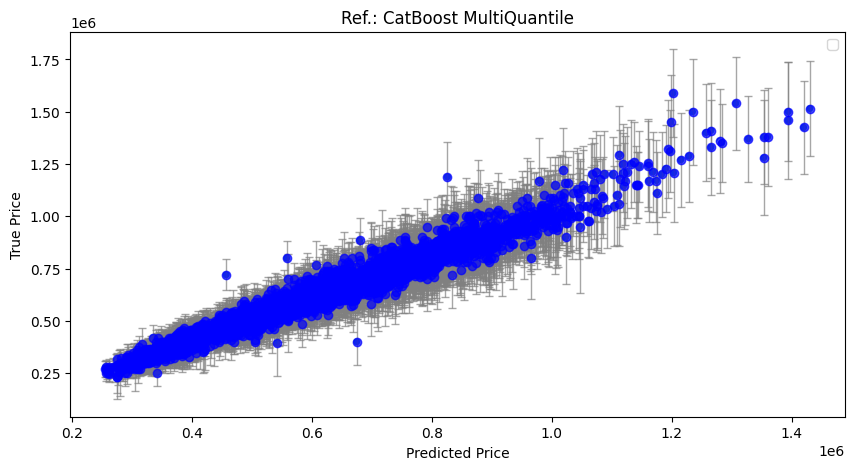

In [47]:
run_name = "Ref.: CatBoost MultiQuantile"
with mlflow.start_run(run_name=run_name):
    print(f'Running: {run_name}')

    # Initialize the CatBoostRegressor for multi-quantile
    model = cb.CatBoostRegressor(
        loss_function=f"MultiQuantile:alpha={quantile_str}",
        cat_features=cat_features,
        **params
    )
    
    # Fit the model
    print('Training the model')
    model.fit(X_train, y_train)

    # Predict on validation
    predictions = model.predict(X_val)
    
    lower_bound = predictions[:, 0] # predictions[:, 0] -> lower 10%
    median_pred = predictions[:, 1] # predictions[:, 1] -> median 50%
    upper_bound = predictions[:, 2] # predictions[:, 2] -> upper 90%
    
    # Log metrics
    log_metrics(run_name, y_val, median_pred, lower_bound, upper_bound)

    # Create a quick plot of the prediction intervals vs. true labels 
    plot_prediction_vs_actual(run_name, y_val, median_pred, lower_bound, upper_bound)
    

In [38]:
df_train['corrected_price_per_sqm'] = df_train['corrected_price'] / df_train['floor_area_sqm']

In [39]:
y_train = df_train['corrected_price_per_sqm'].copy()

Running: Experiment 1: CatBoost MultiQuantile + Price per sqm
Training the model


/Users/henriquecosta/workspace/studies/modern-ml/.venv/lib/python3.11/site-packages/mapie/utils.py:620: UserWarning: WARNING: The predictions are ill-sorted.
  warnings.warn(


Logging metrics to MLflow:  Experiment 1: CatBoost MultiQuantile + Price per sqm  ....
Experiment 1: CatBoost MultiQuantile + Price per sqm
quantile_levels [0.1, 0.5, 0.9]
RMSE: 37087.38012450261
MAPE: 4.409957438049059
MAE: 26499.43057973616
MDAPE: 3.6263170670589204
Coverage: 0.7617257721849976
Interval Width: 78755.38108057166


/var/folders/mc/j147q69d6p7f7t0bjfzgvbs00000gp/T/ipykernel_82212/2069095545.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


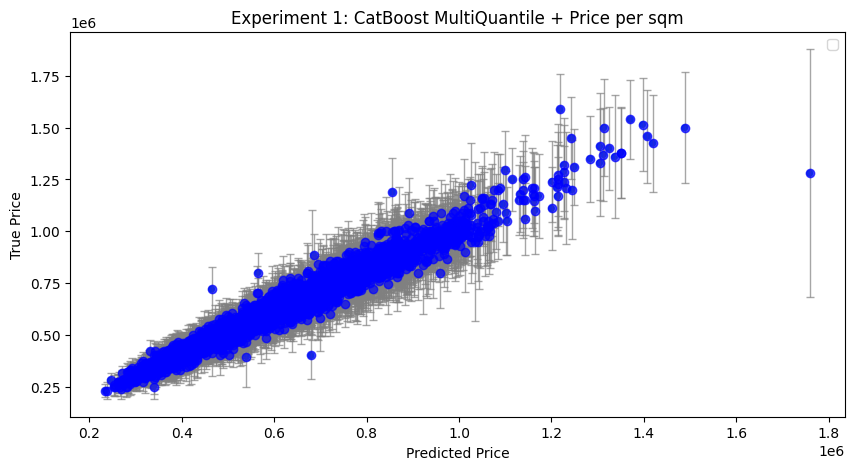

In [40]:
run_name = "Experiment 1: CatBoost MultiQuantile + Price per sqm"
with mlflow.start_run(run_name=run_name):
    print(f'Running: {run_name}')

    # Initialize the CatBoostRegressor for multi-quantile
    model = cb.CatBoostRegressor(
        loss_function=f"MultiQuantile:alpha={quantile_str}",
        cat_features=cat_features,
        **params
    )
    
    # Fit the model
    print('Training the model')
    model.fit(X_train, y_train)

    # Predict on validation
    predictions = model.predict(X_val)
    predictions *= X_val['floor_area_sqm'].values[:, None]
    
    lower_bound = predictions[:, 0] # predictions[:, 0] -> lower 10%
    median_pred = predictions[:, 1] # predictions[:, 1] -> median 50%
    upper_bound = predictions[:, 2] # predictions[:, 2] -> upper 90%
    
    # Log metrics
    log_metrics(run_name, y_val, median_pred, lower_bound, upper_bound)

    # Create a quick plot of the prediction intervals vs. true labels 
    plot_prediction_vs_actual(run_name, y_val, median_pred, lower_bound, upper_bound)

In [29]:
df_train['corrected_price_per_sqm'] = df_train['corrected_price'] / df_train['floor_area_sqm']
df_train['log_corrected_price_per_sqm'] = np.log(df_train['corrected_price_per_sqm'])

In [42]:
y_train = df_train['log_corrected_price_per_sqm'].copy()

Running: Experiment 2: CatBoost MultiQuantile + Log of Price per sqm
Training the model


/Users/henriquecosta/workspace/studies/modern-ml/.venv/lib/python3.11/site-packages/mapie/utils.py:620: UserWarning: WARNING: The predictions are ill-sorted.
  warnings.warn(


Logging metrics to MLflow:  Experiment 2: CatBoost MultiQuantile + Log of Price per sqm  ....
Experiment 2: CatBoost MultiQuantile + Log of Price per sqm
quantile_levels [0.1, 0.5, 0.9]
RMSE: 36894.215881756325
MAPE: 4.379452405296074
MAE: 26335.874996314255
MDAPE: 3.5787237081761263
Coverage: 0.7654845563000491
Interval Width: 77988.8691553745


/var/folders/mc/j147q69d6p7f7t0bjfzgvbs00000gp/T/ipykernel_82212/2069095545.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


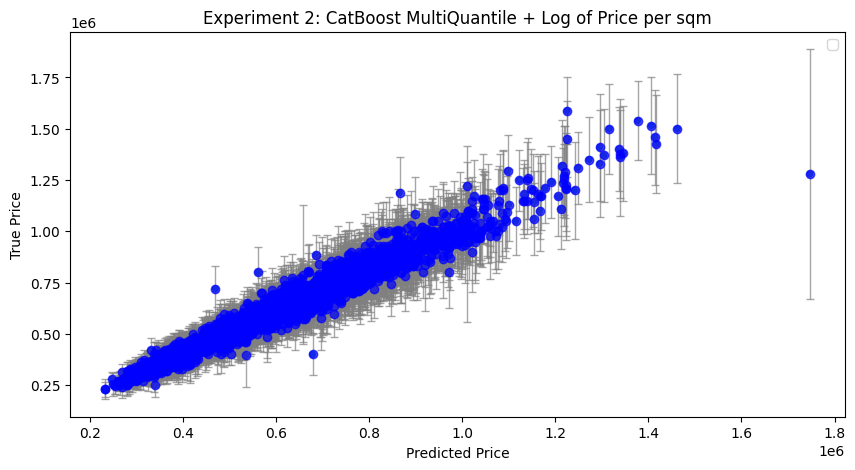

In [ ]:
run_name = "Experiment 2: CatBoost MultiQuantile + Log of Price per sqm"
with mlflow.start_run(run_name=run_name):
    print(f'Running: {run_name}')

    # Initialize the CatBoostRegressor for multi-quantile
    model = cb.CatBoostRegressor(
        loss_function=f"MultiQuantile:alpha={quantile_str}",
        cat_features=cat_features,
        **params
    )
    
    # Fit the model
    print('Training the model')
    model.fit(X_train, y_train)

    # Predict on validation
    predictions = model.predict(X_val)
    predictions = np.exp(predictions)
    predictions *= X_val['floor_area_sqm'].values[:, None]
    
    lower_bound = predictions[:, 0] # predictions[:, 0] -> lower 10%
    median_pred = predictions[:, 1] # predictions[:, 1] -> median 50%
    upper_bound = predictions[:, 2] # predictions[:, 2] -> upper 90%
    
    # Log metrics
    log_metrics(run_name, y_val, median_pred, lower_bound, upper_bound)

    # Create a quick plot of the prediction intervals vs. true labels 
    plot_prediction_vs_actual(run_name, y_val, median_pred, lower_bound, upper_bound)

# Feature Selection

In [16]:
num_features = [f for f in features_list if f not in cat_features]

In [ ]:
# Initialize the random forest regressor
rf = RandomForestRegressor(n_jobs=-1, max_depth=5)

# Initialize Boruta
boruta_selector = BorutaPy(rf, n_estimators=100, max_iter=10, verbose=2, random_state=42)

# Fit Boruta
boruta_selector.fit(X_train[num_features].fillna(-999).values, y_train.values)

In [22]:
# Get the selected features
selected_features = X_train[num_features].columns[boruta_selector.support_].tolist()
print("Selected features:", selected_features)

Selected features: ['floor_area_sqm', 'remaining_lease_years', 'lease_age', 'prior_1_town_std_price_per_sqm', 'prior_3_town_max_price_per_sqm', 'prior_6_town_max_price_per_sqm', 'prior_1_town_street_mean_price_per_sqm', 'prior_1_town_street_max_price_per_sqm', 'prior_3_town_street_mean_price_per_sqm', 'prior_3_town_street_max_price_per_sqm', 'prior_3_town_street_min_price_per_sqm', 'prior_6_town_street_mean_price_per_sqm', 'prior_6_town_street_max_price_per_sqm', 'prior_6_town_street_min_price_per_sqm', 'prior_1_town_street_block_mean_price_per_sqm', 'prior_1_town_street_block_max_price_per_sqm', 'prior_1_town_street_block_min_price_per_sqm', 'prior_3_town_street_block_mean_price_per_sqm', 'prior_3_town_street_block_max_price_per_sqm', 'prior_6_town_street_block_mean_price_per_sqm', 'prior_6_town_street_block_max_price_per_sqm']


In [23]:
selected_features += cat_features

In [44]:
cat_features

['town', 'flat_type', 'storey_range', 'flat_model']

In [24]:
X_train = X_train[selected_features].copy()
X_val = X_val[selected_features].copy()

y_train = df_train['corrected_price'].copy()
y_val = df_val['resale_price'].copy()

Running: Experiment 3: CatBoost MultiQuantile + Boruta Selected Features
Training the model


/Users/henriquecosta/workspace/studies/modern-ml/.venv/lib/python3.11/site-packages/mapie/utils.py:620: UserWarning: WARNING: The predictions are ill-sorted.
  warnings.warn(


Logging metrics to MLflow:  Experiment 3: CatBoost MultiQuantile + Boruta Selected Features  ....
Experiment 3: CatBoost MultiQuantile + Boruta Selected Features
quantile_levels [0.1, 0.5, 0.9]
RMSE: 37434.729541787485
MAPE: 4.480468291832452
MAE: 26933.965364143936
MDAPE: 3.653140404671049
Coverage: 0.7661382578852753
Interval Width: 80557.07135588197


/var/folders/mc/j147q69d6p7f7t0bjfzgvbs00000gp/T/ipykernel_37285/2069095545.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


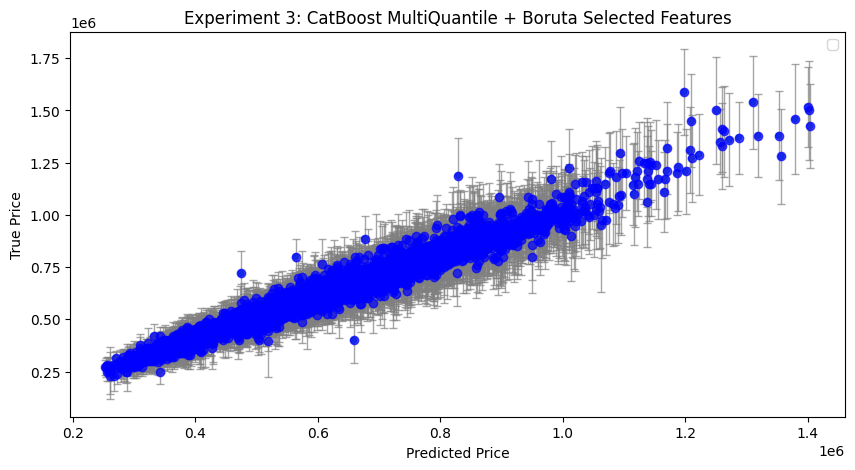

In [25]:
run_name = "Experiment 3: CatBoost MultiQuantile + Boruta Selected Features"
with mlflow.start_run(run_name=run_name):
    print(f'Running: {run_name}')

    # Initialize the CatBoostRegressor for multi-quantile
    model = cb.CatBoostRegressor(
        loss_function=f"MultiQuantile:alpha={quantile_str}",
        cat_features=cat_features,
        **params
    )
    
    # Fit the model
    print('Training the model')
    model.fit(X_train, y_train)

    # Predict on validation
    predictions = model.predict(X_val)
    
    lower_bound = predictions[:, 0] # predictions[:, 0] -> lower 10%
    median_pred = predictions[:, 1] # predictions[:, 1] -> median 50%
    upper_bound = predictions[:, 2] # predictions[:, 2] -> upper 90%
    
    # Log metrics
    log_metrics(run_name, y_val, median_pred, lower_bound, upper_bound)

    # Create a quick plot of the prediction intervals vs. true labels 
    plot_prediction_vs_actual(run_name, y_val, median_pred, lower_bound, upper_bound)

# Hyperparam Tunning

In [33]:
import optuna
from sklearn.model_selection import KFold

In [34]:
y_train = df_train['log_corrected_price_per_sqm'].copy()

In [39]:
def objective(trial: optuna.Trial):
    with mlflow.start_run(nested=True):
        params = dict(
            iterations=500,
            learning_rate=trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            depth=trial.suggest_int('depth', 4, 12),
            l2_leaf_reg=trial.suggest_int('l2_leaf_reg', 1, 20),
            colsample_bylevel=trial.suggest_float('colsample_bylevel', 0.1, 1.0, step=0.1),
            subsample=trial.suggest_float('subsample', 0.1, 1.0, step=0.1),
            loss_function=f"MultiQuantile:alpha={quantile_str}", 
            cat_features=cat_features, 
        )

        model = cb.CatBoostRegressor(**params)
        
        kf = KFold(n_splits=3, shuffle=True, random_state=42)
        scores_coverage = []
        scores_width = []
        for train_index, valid_index in kf.split(X_train):
            X_tr, X_val = X_train.iloc[train_index], X_train.iloc[valid_index]
            y_tr, y_val = y_train.iloc[train_index], y_train.iloc[valid_index]
            
            # Fit the model
            print('Training the model')
            model.fit(X_tr, y_tr)

            # Predict on validation
            predictions = model.predict(X_val)
            predictions = np.exp(predictions)
            predictions *= X_val['floor_area_sqm'].values[:, None]
            
            lower_bound = predictions[:, 0] # predictions[:, 0] -> lower 10%
            upper_bound = predictions[:, 2] # predictions[:, 2] -> upper 90%

            # Log back-transformed validation set
            y_val = np.exp(y_val)
            y_val *= X_val['floor_area_sqm'].values
            
            # Log metrics
            coverage = regression_coverage_score(y_val, lower_bound, upper_bound)
            width = regression_mean_width_score(lower_bound, upper_bound)
            
            scores_coverage.append(coverage)
            scores_width.append(width)
        
        avg_coverage = np.mean(scores_coverage)
        avg_width = np.mean(scores_width)
        mlflow.log_metric('avg_coverage', avg_coverage)
        mlflow.log_metric('avg_width', avg_width)
        mlflow.log_params(params)
    return avg_coverage, avg_width

Training the model
0:	learn: 0.0496035	total: 70.1ms	remaining: 35s
1:	learn: 0.0470949	total: 124ms	remaining: 30.9s
2:	learn: 0.0447875	total: 174ms	remaining: 28.9s
3:	learn: 0.0425446	total: 229ms	remaining: 28.4s
4:	learn: 0.0405111	total: 294ms	remaining: 29.1s
5:	learn: 0.0386063	total: 346ms	remaining: 28.5s
6:	learn: 0.0368271	total: 399ms	remaining: 28.1s
7:	learn: 0.0351816	total: 447ms	remaining: 27.5s
8:	learn: 0.0336671	total: 488ms	remaining: 26.6s
9:	learn: 0.0322885	total: 534ms	remaining: 26.2s
10:	learn: 0.0309887	total: 588ms	remaining: 26.1s
11:	learn: 0.0297978	total: 633ms	remaining: 25.7s
12:	learn: 0.0286941	total: 679ms	remaining: 25.4s
13:	learn: 0.0276661	total: 718ms	remaining: 24.9s
14:	learn: 0.0266981	total: 757ms	remaining: 24.5s
15:	learn: 0.0258108	total: 795ms	remaining: 24s
16:	learn: 0.0250060	total: 830ms	remaining: 23.6s
17:	learn: 0.0242626	total: 870ms	remaining: 23.3s
18:	learn: 0.0235828	total: 909ms	remaining: 23s
19:	learn: 0.0229607	total:

/Users/henriquecosta/workspace/studies/modern-ml/.venv/lib/python3.11/site-packages/mapie/utils.py:620: UserWarning: WARNING: The predictions are ill-sorted.
  warnings.warn(


Training the model
0:	learn: 0.0492469	total: 39.1ms	remaining: 19.5s
1:	learn: 0.0467070	total: 75.8ms	remaining: 18.9s
2:	learn: 0.0443657	total: 108ms	remaining: 17.8s
3:	learn: 0.0421556	total: 147ms	remaining: 18.2s
4:	learn: 0.0401207	total: 242ms	remaining: 24s
5:	learn: 0.0382525	total: 302ms	remaining: 24.8s
6:	learn: 0.0365112	total: 351ms	remaining: 24.7s
7:	learn: 0.0348929	total: 393ms	remaining: 24.2s
8:	learn: 0.0333934	total: 447ms	remaining: 24.4s
9:	learn: 0.0319976	total: 505ms	remaining: 24.8s
10:	learn: 0.0307162	total: 548ms	remaining: 24.4s
11:	learn: 0.0295328	total: 588ms	remaining: 23.9s
12:	learn: 0.0284328	total: 627ms	remaining: 23.5s
13:	learn: 0.0274219	total: 673ms	remaining: 23.4s
14:	learn: 0.0265038	total: 708ms	remaining: 22.9s
15:	learn: 0.0256434	total: 738ms	remaining: 22.3s
16:	learn: 0.0248303	total: 780ms	remaining: 22.2s
17:	learn: 0.0241107	total: 827ms	remaining: 22.1s
18:	learn: 0.0234413	total: 867ms	remaining: 21.9s
19:	learn: 0.0228201	t

/Users/henriquecosta/workspace/studies/modern-ml/.venv/lib/python3.11/site-packages/mapie/utils.py:620: UserWarning: WARNING: The predictions are ill-sorted.
  warnings.warn(


Training the model
0:	learn: 0.0496328	total: 79.6ms	remaining: 39.7s
1:	learn: 0.0470968	total: 157ms	remaining: 39s
2:	learn: 0.0447527	total: 203ms	remaining: 33.7s
3:	learn: 0.0425155	total: 263ms	remaining: 32.6s
4:	learn: 0.0404448	total: 314ms	remaining: 31.1s
5:	learn: 0.0385305	total: 374ms	remaining: 30.8s
6:	learn: 0.0367912	total: 442ms	remaining: 31.1s
7:	learn: 0.0351508	total: 498ms	remaining: 30.6s
8:	learn: 0.0336515	total: 554ms	remaining: 30.2s
9:	learn: 0.0322513	total: 596ms	remaining: 29.2s
10:	learn: 0.0309683	total: 660ms	remaining: 29.3s
11:	learn: 0.0297707	total: 716ms	remaining: 29.1s
12:	learn: 0.0286695	total: 793ms	remaining: 29.7s
13:	learn: 0.0276238	total: 869ms	remaining: 30.2s
14:	learn: 0.0267034	total: 927ms	remaining: 30s
15:	learn: 0.0258494	total: 1.05s	remaining: 31.7s
16:	learn: 0.0250558	total: 1.09s	remaining: 30.9s
17:	learn: 0.0242963	total: 1.13s	remaining: 30.3s
18:	learn: 0.0236206	total: 1.17s	remaining: 29.7s
19:	learn: 0.0229945	tota

...

/Users/henriquecosta/workspace/studies/modern-ml/.venv/lib/python3.11/site-packages/mapie/utils.py:620: UserWarning: WARNING: The predictions are ill-sorted.
  warnings.warn(


Number of trials on the Pareto front: 10
Training the model


/Users/henriquecosta/workspace/studies/modern-ml/.venv/lib/python3.11/site-packages/mapie/utils.py:620: UserWarning: WARNING: The predictions are ill-sorted.
  warnings.warn(


Logging metrics to MLflow:  Experiment 3: CatBoost MultiQuantile + Boruta Selected Features  ....
Experiment 3: CatBoost MultiQuantile + Boruta Selected Features
quantile_levels [0.1, 0.5, 0.9]
RMSE: 616690.5704870098
MAPE: 99.99839182099387
MAE: 589777.3389737657
MDAPE: 99.99848254687078
Coverage: 0.0
Interval Width: 0.13486903591372904


/var/folders/mc/j147q69d6p7f7t0bjfzgvbs00000gp/T/ipykernel_37285/2069095545.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


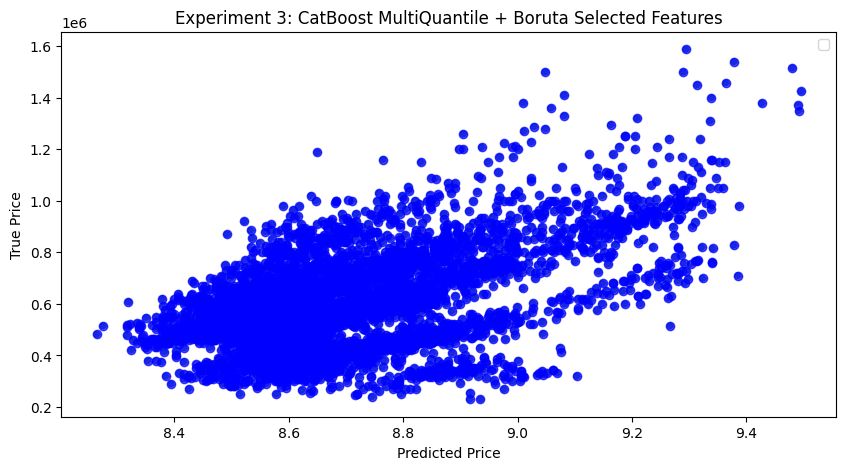

In [40]:
optuna.logging.set_verbosity(optuna.logging.ERROR)


with mlflow.start_run():
    study = optuna.create_study(directions=["maximize", "minimize"])

    study.optimize(objective, n_trials=10)

    print(f"Number of trials on the Pareto front: {len(study.best_trials)}")

    trial_with_highest_coverage = max(study.best_trials, key=lambda t: t.values[0])

    mlflow.log_params(trial_with_highest_coverage.params)
    mlflow.log_metric("avg_coverage", trial_with_highest_coverage.values[0])
    mlflow.log_metric("avg_width", trial_with_highest_coverage.values[1])

    # Fit the model
    print('Training the model')
    model.fit(X_train, y_train)

    # Predict on validation
    predictions = model.predict(X_val)
    
    lower_bound = predictions[:, 0] # predictions[:, 0] -> lower 10%
    median_pred = predictions[:, 1] # predictions[:, 1] -> median 50%
    upper_bound = predictions[:, 2] # predictions[:, 2] -> upper 90%
    
    # Log metrics
    log_metrics(run_name, y_val, median_pred, lower_bound, upper_bound)

    # Create a quick plot of the prediction intervals vs. true labels 
    plot_prediction_vs_actual(run_name, y_val, median_pred, lower_bound, upper_bound)

In [41]:
optuna.visualization.plot_pareto_front(study, target_names=["coverage", "width"])

In [42]:
optuna.visualization.plot_param_importances(
    study, target=lambda t: t.values[0], target_name="coverage"
)

In [43]:
optuna.visualization.plot_param_importances(
    study, target=lambda t: t.values[0], target_name="width"
)